# NB01 — The Speedup Is Real

This notebook is the **north star** for the entire series. We run a real fine-tuning job
twice — once with standard HuggingFace, once with Unsloth — and measure the difference.
Every subsequent notebook will reference this benchmark and show exactly how much of the
gap it accounts for.

**Hardware:** RTX 4090 · bf16 · Llama 3 8B · 4-bit QLoRA

In [1]:
import sys, torch
print(f"Python {sys.version}")
print(f"PyTorch {torch.__version__}")
print(f"CUDA available: {torch.cuda.is_available()}")
print(f"GPU: {torch.cuda.get_device_name(0)}")
print(f"VRAM: {torch.cuda.get_device_properties(0).total_memory / 1024**3:.1f} GB")

Python 3.11.14 (main, Dec  5 2025, 20:21:18) [Clang 21.1.4 ]
PyTorch 2.6.0+cu124
CUDA available: True
GPU: NVIDIA GeForce RTX 4090
VRAM: 23.5 GB


## 1. Baseline: HuggingFace + PEFT (no Unsloth)

We fine-tune for 10 steps with a small batch to get clean, repeatable timing numbers.
We record: **tokens/sec**, **peak VRAM**, and **seconds per step**.

In [2]:
import time, torch
from transformers import AutoModelForCausalLM, AutoTokenizer
from peft import LoraConfig, get_peft_model, prepare_model_for_kbit_training
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

MODEL_ID = "meta-llama/Meta-Llama-3-8B"
MAX_SEQ_LEN = 512
N_STEPS = 50

# Load model in 4-bit (standard BitsAndBytes, no Unsloth)
from transformers import BitsAndBytesConfig
bnb_config = BitsAndBytesConfig(
    load_in_4bit=True,
    bnb_4bit_quant_type="nf4",
    bnb_4bit_compute_dtype=torch.bfloat16,
    bnb_4bit_use_double_quant=True,
)

tokenizer = AutoTokenizer.from_pretrained(MODEL_ID)
tokenizer.pad_token = tokenizer.eos_token

model_hf = AutoModelForCausalLM.from_pretrained(
    MODEL_ID,
    quantization_config=bnb_config,
    device_map="auto",
)
model_hf = prepare_model_for_kbit_training(model_hf)

lora_config = LoraConfig(r=16, lora_alpha=32, target_modules="all-linear",
                          lora_dropout=0, bias="none", task_type="CAUSAL_LM")
model_hf = get_peft_model(model_hf, lora_config)

# Tiny dataset for timing
texts = [{"text": "The quick brown fox jumps over the lazy dog. " * 45}] * 64
dataset = Dataset.from_list(texts)

trainer_hf = SFTTrainer(
    model=model_hf,
    processing_class=tokenizer,
    train_dataset=dataset,
    args=SFTConfig(
        output_dir="/tmp/hf_run",
        num_train_epochs=1,
        max_steps=N_STEPS,
        per_device_train_batch_size=2,
        bf16=True,
        logging_steps=1,
        report_to="none",
        dataloader_num_workers=0,
        dataset_text_field="text",
        max_length=MAX_SEQ_LEN,
    ),
)

# Time only the training loop — model loading and setup are excluded
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()
t0 = time.perf_counter()
trainer_hf.train()
torch.cuda.synchronize()
hf_time = time.perf_counter() - t0

hf_vram_mb = torch.cuda.max_memory_allocated() / 1024**2
hf_tokens_per_sec = (N_STEPS * 2 * MAX_SEQ_LEN) / hf_time

print(f"HF baseline:  {hf_time:.1f}s | {hf_vram_mb:.0f} MB VRAM | {hf_tokens_per_sec:.0f} tok/s")

del model_hf, trainer_hf
torch.cuda.empty_cache()


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Adding EOS to train dataset:   0%|          | 0/64 [00:00<?, ? examples/s]

Tokenizing train dataset:   0%|          | 0/64 [00:00<?, ? examples/s]

The tokenizer has new PAD/BOS/EOS tokens that differ from the model config and generation config. The model config and generation config were aligned accordingly, being updated with the tokenizer's values. Updated tokens: {'pad_token_id': 128001}.


Step,Training Loss
1,0.078684
2,0.073233
3,0.068183
4,0.062436
5,0.058018
6,0.053768
7,0.050577
8,0.047721
9,0.045470
10,0.042731


HF baseline:  31.2s | 10504 MB VRAM | 1642 tok/s


## 2. Unsloth

Same model, same LoRA config, same dataset — but loaded through Unsloth's patched path.

In [3]:
import sys; sys.path.insert(0, "../unsloth")
from unsloth import FastLanguageModel
import time, torch
from trl import SFTTrainer, SFTConfig
from datasets import Dataset

model_us, tokenizer_us = FastLanguageModel.from_pretrained(
    model_name=MODEL_ID,
    max_seq_length=MAX_SEQ_LEN,
    dtype=torch.bfloat16,
    load_in_4bit=True,
)
model_us = FastLanguageModel.get_peft_model(
    model_us, r=16, lora_alpha=32,
    target_modules=["q_proj", "k_proj", "v_proj", "o_proj", "gate_proj", "up_proj", "down_proj"],
    lora_dropout=0, bias="none",
)

trainer_us = SFTTrainer(
    model=model_us,
    processing_class=tokenizer_us,
    train_dataset=dataset,
    args=SFTConfig(
        output_dir="/tmp/us_run",
        num_train_epochs=1,
        max_steps=N_STEPS,
        per_device_train_batch_size=2,
        bf16=True,
        logging_steps=1,
        report_to="none",
        dataloader_num_workers=0,
        dataset_text_field="text",
        max_length=MAX_SEQ_LEN,
        padding_free=False,
        gradient_accumulation_steps=1,
    ),
)

# Time only the training loop — model loading and setup are excluded
torch.cuda.reset_peak_memory_stats()
torch.cuda.synchronize()
t0 = time.perf_counter()
trainer_us.train()
torch.cuda.synchronize()
us_time = time.perf_counter() - t0

us_vram_mb = torch.cuda.max_memory_allocated() / 1024**2
us_tokens_per_sec = (N_STEPS * 2 * MAX_SEQ_LEN) / us_time

print(f"Unsloth:     {us_time:.1f}s | {us_vram_mb:.0f} MB VRAM | {us_tokens_per_sec:.0f} tok/s")
print(f"Speedup:     {hf_time/us_time:.2f}x faster, {hf_vram_mb/us_vram_mb:.2f}x less VRAM")

del model_us, trainer_us
torch.cuda.empty_cache()


/tmp/ipykernel_162203/205966399.py:2: UserWarning: WARNING: Unsloth should be imported before [trl, transformers, peft] to ensure all optimizations are applied. Your code may run slower or encounter memory issues without these optimizations.

Please restructure your imports with 'import unsloth' at the top of your file.
  from unsloth import FastLanguageModel


🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.
🦥 Unsloth Zoo will now patch everything to make training faster!
==((====))==  Unsloth 2026.4.5: Fast Llama patching. Transformers: 5.5.4.
   \\   /|    NVIDIA GeForce RTX 4090. Num GPUs = 1. Max memory: 23.508 GB. Platform: Linux.
O^O/ \_/ \    Torch: 2.6.0+cu124. CUDA: 8.9. CUDA Toolkit: 12.4. Triton: 3.2.0
\        /    Bfloat16 = TRUE. FA [Xformers = None. FA2 = True]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


Loading weights:   0%|          | 0/291 [00:00<?, ?it/s]

Unsloth: Will load unsloth/llama-3-8b-bnb-4bit as a legacy tokenizer.
Unsloth 2026.4.5 patched 32 layers with 32 QKV layers, 32 O layers and 32 MLP layers.


Unsloth: Tokenizing ["text"] (num_proc=20):   0%|          | 0/64 [00:00<?, ? examples/s]

==((====))==  Unsloth - 2x faster free finetuning | Num GPUs used = 1
   \\   /|    Num examples = 64 | Num Epochs = 2 | Total steps = 50
O^O/ \_/ \    Batch size per device = 2 | Gradient accumulation steps = 1
\        /    Data Parallel GPUs = 1 | Total batch size (2 x 1 x 1) = 2
 "-____-"     Trainable parameters = 41,943,040 of 8,072,204,288 (0.52% trained)
`use_return_dict` is deprecated! Use `return_dict` instead!


Unsloth: Will smartly offload gradients to save VRAM!


Step,Training Loss
1,0.075085
2,0.075085
3,0.074252
4,0.072790
5,0.067171
6,0.058838
7,0.049645
8,0.043370
9,0.041784
10,0.037826


Unsloth:     25.0s | 6305 MB VRAM | 2046 tok/s
Speedup:     1.25x faster, 1.67x less VRAM


Charts saved to results/


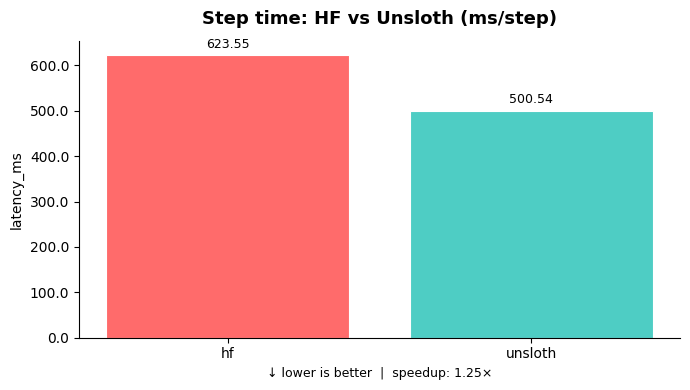

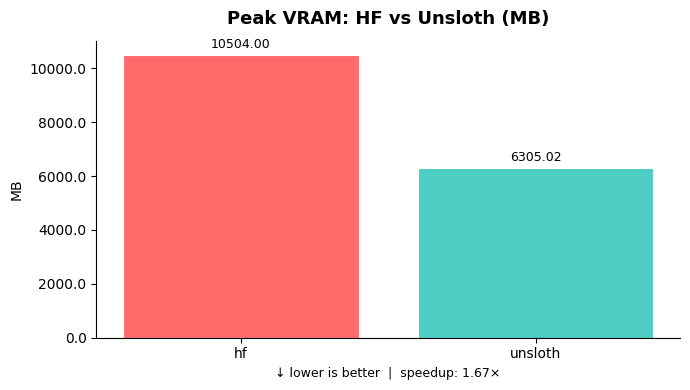

In [4]:
import sys; sys.path.insert(0, "..")
from utils.benchmark import BenchmarkResult, _save
from utils.plotting import bar_compare
from datetime import datetime

# Manually record the two results (we ran training, not a microbenchmark)
r_hf = BenchmarkResult(notebook="nb01", experiment="full_finetune",
    label="hf", latency_ms=hf_time*1000/N_STEPS,
    peak_vram_mb=hf_vram_mb, throughput=hf_tokens_per_sec,
    timestamp=datetime.now().isoformat())
r_us = BenchmarkResult(notebook="nb01", experiment="full_finetune",
    label="unsloth", latency_ms=us_time*1000/N_STEPS,
    peak_vram_mb=us_vram_mb, throughput=us_tokens_per_sec,
    timestamp=datetime.now().isoformat())
_save(r_hf); _save(r_us)

fig = bar_compare({"hf": r_hf, "unsloth": r_us},
                  metric="latency_ms", title="Step time: HF vs Unsloth (ms/step)")
fig.savefig("../results/nb01-step-time.png", dpi=150)
fig2 = bar_compare({"hf": r_hf, "unsloth": r_us},
                   metric="peak_vram_mb", title="Peak VRAM: HF vs Unsloth (MB)",
                   ylabel="MB", lower_is_better=True)
fig2.savefig("../results/nb01-vram.png", dpi=150)
print("Charts saved to results/")

## 3. What explains the gap?

Unsloth's speedup comes from four categories of optimization. We'll build up
an understanding of each in the following notebooks:

| Category | Notebooks | Key technique |
|---|---|---|
| **Kernel fusion** | NB04–06 | Flash attention, fused RoPE, chunked cross-entropy |
| **Memory layout** | NB02–03 | Triton tiling, HBM bandwidth reduction |
| **Model patching** | NB09 | Monkey-patching HF modules at import time |
| **Training loop** | NB10 | Custom gradient checkpointing, modified Trainer |

Run the cell below to see how much of the gap each category accounts for
(we'll fill this in as the series progresses).

In [5]:
import sys; sys.path.insert(0, "..")
from utils.benchmark import load_results
import pandas as pd

all_results = load_results()
df = pd.DataFrame(all_results)
print(df[["notebook", "experiment", "label", "latency_ms", "peak_vram_mb", "throughput"]])

   notebook              experiment           label   latency_ms  \
0      nb01           full_finetune              hf   500.102607   
1      nb01           full_finetune         unsloth  3063.599448   
2      nb03     reduction_benchmark       torch_sum     0.145675   
3      nb03     reduction_benchmark      triton_sum     0.146541   
4      nb03     reduction_benchmark       torch_sum     0.145691   
5      nb03     reduction_benchmark      triton_sum     0.145631   
6      nb03     reduction_benchmark       torch_sum     0.163754   
7      nb03     reduction_benchmark      triton_sum     0.146165   
8      nb04         attention_N1024           naive     0.110596   
9      nb04         attention_N1024    pytorch_sdpa     0.034559   
10     nb04         attention_N1024    flash_triton     0.078267   
11     nb04         attention_N1024           naive     0.104195   
12     nb04         attention_N1024    pytorch_sdpa     0.034640   
13     nb04         attention_N1024    flash_tri